# Machine learning and deep learning with Tensorflow/Keras:
TensorFlow is a software library that allows you to create and train machine learning models. It provides a set of tools and functions that enable you to define and manipulate mathematical operations on multi-dimensional arrays called tensors. These tensors are used to represent the input data and the parameters of the model, which are optimized during the training process to make accurate predictions. TensorFlow also includes a high-level API called Keras, which simplifies the process of building and training neural networks.


## Building Your First Neural Network
Let's run the same example we went through last time but now using Tensorflow/Keras.

1. First, we import TensorFlow, the Keras API for TensorFlow, and NumPy for array manipulation.
2. We load the MNIST dataset using the Keras API and split it into a training set and a test set.
3. We normalize the pixel values of the images to be between 0 and 1.
4. We define the model architecture using the Keras Sequential API. This model has one input layer, one hidden layer with 128 neurons and ReLU activation, and one output layer with 10 neurons (one for each digit).
5. We compile the model, specifying the optimizer (Adam), the loss function (sparse categorical cross-entropy), and the metric to monitor during training (accuracy).
6. We train the model on the training set for 10 epochs.
7. We evaluate the model on the test set and print the test accuracy.
8. Finally, we make predictions on the first three images in the test set and print the predicted labels.


You can modify this code to add more layers, change the number of neurons, change the activation functions, or use different datasets. The TensorFlow documentation has many more examples and tutorials that you can use to learn more about machine learning with TensorFlow.

train_images.shape:  (60000, 28, 28)
train_labels:  (60000,)
test_images.shape:  (10000, 28, 28)
test_labels:  (10000,)


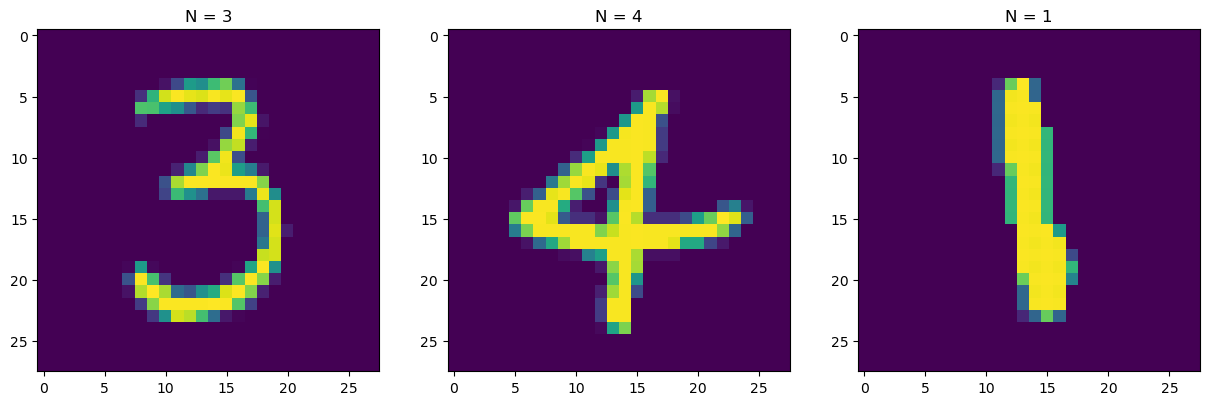

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9316 - loss: 0.2323 
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9699 - loss: 0.0968
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9787 - loss: 0.0676
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9831 - loss: 0.0535 
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9867 - loss: 0.0409
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9888 - loss: 0.0342 
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9906 - loss: 0.0281 
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9921 - loss: 0.0242
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9930 - loss: 0.0209
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9930 - loss: 0.0200 
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9771 - loss: 0.1003
Test accuracy: 0.97710001

In [6]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

#%% Preparing the Data --------------------------------------------------
# Load the MNIST dataset
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

#%% Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

print('train_images.shape: ', train_images.shape)
print('train_labels: ', train_labels.shape)
print('test_images.shape: ', test_images.shape)
print('test_labels: ', test_labels.shape)

#%% 
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(train_images[50,:,:])
plt.title('N = {}'.format(train_labels[50]))

plt.subplot(1,3,2)
plt.imshow(train_images[150,:,:])
plt.title('N = {}'.format(train_labels[150]))

plt.subplot(1,3,3)
plt.imshow(train_images[200,:,:])
plt.title('N = {}'.format(train_labels[200]))
plt.show()

#-------------------------------------------------------------------------

#%% Building the Model ---------------------------------------------------
# Define the model architecture
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)
])

# Compile the model (uisng adaptive moment estimation optimization algorithm)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
#-------------------------------------------------------------------------

#%%   Training the Model  ------------------------------------------------
# Train the model    
model.fit(train_images, train_labels, epochs=10)
model.save_weights('NET.weights.h5')


# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc)
#-------------------------------------------------------------------------

#%% Make predictions on a few images  ------------------------------------
predictions = model.predict(test_images[:3])
predicted_labels = np.argmax(predictions, axis=1)
print('Predicted labels:', predicted_labels)
#-------------------------------------------------------------------------


In [5]:
#-------------------------------------------------------------------------
#%% Using the model       ------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten


#%% Building the Model ---------------------------------------------------
# Define the model architecture
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)
])

# Load the model's saved weights.
model.load_weights('NET.weights.h5')


# Predict on the first 5 test images.
predictions = model.predict(test_images[:5])

# Print our model's predictions.
print(np.argmax(predictions, axis=1)) # [7, 2, 1, 0, 4]

# Check our predictions against the ground truths.
print(test_labels[:5]) # [7, 2, 1, 0, 4]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
[7 2 1 0 4]
[7 2 1 0 4]
